<a href="https://colab.research.google.com/github/azholl/lis5693/blob/main/lab-7/lab-7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing Libraries**

In [11]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

Loading data from lab 4, renaming columns, adding ObjectId column.

In [12]:
import requests
import io

url = "https://raw.githubusercontent.com/azholl/lis5693/main/lab-4/SMSSpamCollection.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text

df = pd.read_csv(io.StringIO(text))
df.columns = ['Label', 'Description']
df['ObjectId'] = range(1, len(df) + 1)
print(df.head())

  Label                                        Description  ObjectId
0   ham  Go until jurong point, crazy.. Available only ...         1
1   ham                      Ok lar... Joking wif u oni...         2
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...         3
3   ham  U dun say so early hor... U c already then say...         4
4   ham  Nah I don't think he goes to usf, he lives aro...         5


Creating new dataframe with 'id' and 'text' field. The 'text' field in my dataset is just the contents of the text messages, which I have labeled as description.

In [13]:
df_subset = df[['ObjectId', 'Description']].copy()

Removing all non-alphabet characters and converting to lower-case

In [14]:
df_subset['Description'] = df_subset['Description'].str.replace("[^a-zA-Z#]", "   ")
df_subset['Description'] = df_subset['Description'].str.casefold()
print(df_subset.head(10))

   ObjectId                                        Description
0         1  go until jurong point, crazy.. available only ...
1         2                      ok lar... joking wif u oni...
2         3  free entry in 2 a wkly comp to win fa cup fina...
3         4  u dun say so early hor... u c already then say...
4         5  nah i don't think he goes to usf, he lives aro...
5         6  freemsg hey there darling it's been 3 week's n...
6         7  even my brother is not like to speak with me. ...
7         8  as per your request 'melle melle (oru minnamin...
8         9  winner!! as a valued network customer you have...
9        10  had your mobile 11 months or more? u r entitle...


**Generating Sentiment Polarity Scores**

Creating a dataframe for staging the output of the SentimentIntensityAnalyzer.polarity_scores method.

In [15]:
df1 = pd.DataFrame()
df1['ObjectId'] = ['9999999999999']
df1['sentiment_type'] = 'NA99NA'
df1['sentiment_score'] = 0

Instantiating an object of SentimentIntensityAnalyzer and running a for-loop to iterate the polarity_scores method over each row of df_subset. Cleaning the output dataframe.

In [16]:
print('Processing sentiment analysis...')
sid = SentimentIntensityAnalyzer()

all_scores_list = [] # Use a list to collect results

for index, row in df_subset.iterrows():
    scores = sid.polarity_scores(row['Description']) # Access by column name for clarity and robustness
    for key, value in scores.items():
        all_scores_list.append({
            'ObjectId': row['ObjectId'], # Access by column name
            'sentiment_type': key,
            'sentiment_score': value
        })

# Create a DataFrame from the list of dictionaries after the loop
t_df_all_types = pd.DataFrame(all_scores_list)

# Filter for compound sentiment and remove duplicates
t_df_cleaned = t_df_all_types[t_df_all_types.sentiment_type == 'compound'].drop_duplicates()

print(t_df_cleaned.head(10))

Processing sentiment analysis...
    ObjectId sentiment_type  sentiment_score
3          1       compound           0.6249
7          2       compound           0.4767
11         3       compound           0.7964
15         4       compound           0.0000
19         5       compound          -0.1027
23         6       compound           0.8802
27         7       compound          -0.1331
31         8       compound           0.4767
35         9       compound           0.9390
39        10       compound           0.8513


Merge t_df_cleaned with df using the id field. I used the common column 'ObjectId' to merge the original dataset with the sentiment scores. I had to add a unique ObjectId column because the only columns originally were the text message column and the label column (spam/ham label). I misunderstood the assignment and tried to make the label column function as an ObjectId column and got an output that was just duplicates over and over again. It took me searching through several threads to understand why that error was happening and how to add a unique ID column to a pandas df (which I found the code to do here under the Key Takeaway and FAQ section: https://codegive.com/blog/pandas_id_column.php)

In [17]:
df_output = pd.merge(df, t_df_cleaned, on='ObjectId', how='inner')
print(df_output.head(10))

  Label                                        Description  ObjectId  \
0   ham  Go until jurong point, crazy.. Available only ...         1   
1   ham                      Ok lar... Joking wif u oni...         2   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...         3   
3   ham  U dun say so early hor... U c already then say...         4   
4   ham  Nah I don't think he goes to usf, he lives aro...         5   
5  spam  FreeMsg Hey there darling it's been 3 week's n...         6   
6   ham  Even my brother is not like to speak with me. ...         7   
7   ham  As per your request 'Melle Melle (Oru Minnamin...         8   
8  spam  WINNER!! As a valued network customer you have...         9   
9  spam  Had your mobile 11 months or more? U R entitle...        10   

  sentiment_type  sentiment_score  
0       compound           0.6249  
1       compound           0.4767  
2       compound           0.7964  
3       compound           0.0000  
4       compound          -

In [18]:
df_output[["sentiment_score"]].describe()

,sentiment_score
count,5574.000000
mean,0.190841
std,0.411603
min,-0.931900
25%,0.000000
50%,0.000000
75%,0.524200
max,0.997500


The sentiment polarity results show that the overall sentiment of the dataset is slightly positive with a mean score of 0.1908. The median value is 0, which indicates that many of the messages are neutral or do not contain strong sentiment. The minimum and maximum values being so close to -1 and 1 show that the intensity of the most negative response is strongly negative, and the intensity of the most positive response is strongly positive. The 0.4116 standard deviation suggests there is a moderate amount of variation in sentiment scores, but the mean shows that most messages tend to cluster around neutral to slightly positive sentiment.

Using Seaborn boxplot to visualize sentiment scores between spam and ham messages.

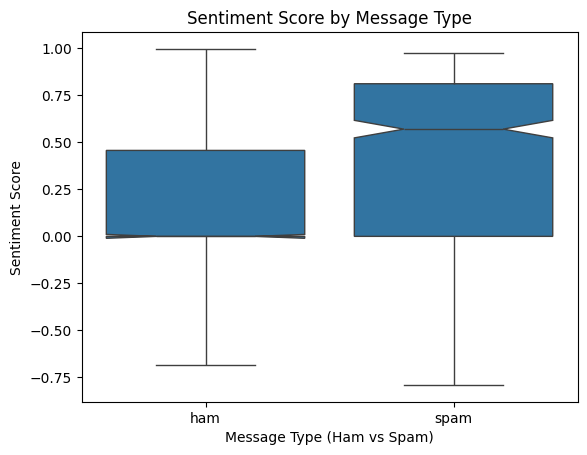

In [20]:
import seaborn as sns
#create seaborn boxplots by group

sns.boxplot(x='Label', y='sentiment_score', notch=True,
    data=df_output, showfliers=False).set(title='Sentiment Score by Message Type')
#modifying axis labels
plt.xlabel('Message Type (Ham vs Spam)')
plt.ylabel('Sentiment Score')
plt.show()

This visualization shows that ham messages have a median sentiment score close to 0, indicating that most of them are neutral, or only slightly positive or negative. Spam messages have a higher median sentiment score, which means they tend to be more positive overall. The spread of the spam messages being wider also indicates greater variation in sentiment when compared to ham messages.

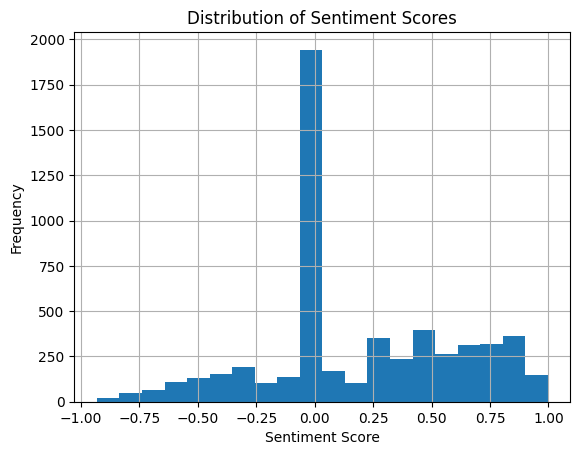

In [22]:
df_output['sentiment_score'].hist(bins=20).set(title='Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.show()

I decided to run a histogram of the distribution of the sentiment scores since the other examples of visualizations in our lab instructions didn't seem to translate to my dataset. I searched until I found this thread that explained how to do it in this context: https://stackoverflow.com/questions/54353864/selecting-a-column-to-make-histogram

The results of the histogram show that a vast majority of messages in this dataset are neutral. The ones that aren't skew more toward having positive sentiment rather than negative sentiment.

**Reflection**
The main challenge that I encountered when doing this lab was not understanding what the ObjectId column represented. When following along with the lab notebook instructions at the beginning, I mistakenly thought that the 'label' column in my dataset (labeling spam/ham messages) could be used as the ObjectId column. Whenever I labeled it so and used it to merge the dataframes, there were many duplicates rows. I searched about panda merge duplicating rows and found a reddit comment suggesting using "validate='1:1' in the merge statement" to check if my dataframes have rows with the same instance_id. When I did that, I got a merge error "Merge keys are not unique in either left or right dataset". I searched this error and finally understood that the column I was using to merge shouldn't contain duplicate values or else I will get the repetition. Obviously using the label as the ObjectId column was incorrect and I needed to create a unique identifier column so that each row could be matched correctly during the merge. Once I did that, the rest of the sentiment analysis went well. The other issue I encountered was needing to use a different visualization than the examples we were shown in the lab as I felt like everything except the boxplot would not translate well. It only took a few searches to find example code for plotting a histogram graph from a column.

I am interested in working as a health data analyst after I graduate, and it looks like there are many uses for sentiment analysis in this field. I saw papers where researchers use it for greater research into health trends and public sentiments towards health and science related things, and many examples of clinics using it to analyze patient feedback.